In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if (Path.cwd().parent / "pyproject.toml").exists() else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

from src.config import HF_REPO_ID

In [2]:
# lido direto do dataset público do time no Hugging Face Hub, sem precisar rodar o pipeline localmente
df_data = pd.read_parquet(f"hf://datasets/{HF_REPO_ID}/interim/diesel/diesel.parquet")

In [3]:
df_data

,regiao_sigla,estado_sigla,municipio,revenda,cnpj_da_revenda,nome_da_rua,numero_da_rua,complemento,bairro,cep,produto,data_da_coleta,valor_de_venda,valor_de_compra,unidade_de_medida,bandeira,file_name
0,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,306,NaN,JARDIM ZULMIRA,18061-000,DIESEL S10,2023-01-03,6.21,NaN,R$ / litro,BRANCA,Preços semestrais - AUTOMOTIVOS_2023.01.csv
1,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL 220 - KM 06,S/N,NaN,PLANALTO,57308-000,DIESEL,2023-01-02,6.49,NaN,R$ / litro,VIBRA ENERGIA,Preços semestrais - AUTOMOTIVOS_2023.01.csv
2,NE,AL,ARAPIRACA,IBN PINTO E SILVA & CIA LTDA,01.242.690/0001-58,RODOVIA AL-110,678,KM 70,CANAFISTULA,57302-802,DIESEL,2023-01-02,6.89,NaN,R$ / litro,IPIRANGA,Preços semestrais - AUTOMOTIVOS_2023.01.csv
3,NE,AL,ARAPIRACA,IBN PINTO E SILVA & CIA LTDA,01.242.690/0002-39,"AVENIDA EMIDIO DE LIMA,",23,NaN,JARDIM ESPERANCA,57304-820,DIESEL,2023-01-02,6.99,NaN,R$ / litro,IPIRANGA,Preços semestrais - AUTOMOTIVOS_2023.01.csv
4,N,AM,PARINTINS,F.J. COMERCIO DE COMBUSTIVEIS LTDA,09.368.602/0001-70,RUA PARAIBA,41,CONJ MACURANY,RAIMUNDO MUNIZ,69151-456,DIESEL S10,2023-01-05,8.38,NaN,R$ / litro,BRANCA,Preços semestrais - AUTOMOTIVOS_2023.01.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8196136,NE,BA,IRECE,AUTO POSTO NORDESTE LTDA,35.621.319/0001-19,RUA BELEM,S/N,TERREO,BAIXAO DE SINEZIA,44900-000,DIESEL S10,2022-06-30,8.33,NaN,R$ / litro,BRANCA,precos-semestrais-ca-2022-01.csv
8196137,NE,BA,IRECE,AUTO POSTO NORDESTE LTDA,35.621.319/0001-19,RUA BELEM,S/N,TERREO,BAIXAO DE SINEZIA,44900-000,DIESEL,2022-06-30,8.23,NaN,R$ / litro,BRANCA,precos-semestrais-ca-2022-01.csv
8196138,CO,MT,CUIABA,OZ REVENDEDORA DE COMBUSTIVEIS LTDA,36.757.198/0001-08,AVENIDA SENADOR METELLO,868,NaN,CENTRO-SUL,78020-600,DIESEL S10,2022-06-30,7.69,NaN,R$ / litro,BRANCA,precos-semestrais-ca-2022-01.csv
8196139,NE,MA,CAXIAS,POSTAO COMERCIO DE COMBUSTIVEIS LTDA,31.597.569/0001-00,RODOVIA BR-316,S/N,KM 552 SALA A,VOLTA REDONDA,65606-525,DIESEL S10,2022-06-30,7.59,NaN,R$ / litro,BRANCA,precos-semestrais-ca-2022-01.csv


8.196.141 linhas, 17 colunas, já filtradas para `produto` contendo "DIESEL" (feito no `clean.py`). Cada linha é uma coleta de preço em um posto revendedor específico (não um preço nacional agregado) - os agregados por período/região nas próximas células são todos calculados a partir desses registros individuais.

In [4]:
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8196141 entries, 0 to 8196140
Data columns (total 17 columns):
 #   Column             Dtype         
---  ------             -----         
 0   regiao_sigla       str           
 1   estado_sigla       str           
 2   municipio          str           
 3   revenda            str           
 4   cnpj_da_revenda    str           
 5   nome_da_rua        str           
 6   numero_da_rua      str           
 7   complemento        str           
 8   bairro             str           
 9   cep                str           
 10  produto            str           
 11  data_da_coleta     datetime64[us]
 12  valor_de_venda     float64       
 13  valor_de_compra    float64       
 14  unidade_de_medida  str           
 15  bandeira           str           
 16  file_name          str           
dtypes: datetime64[us](1), float64(2), str(14)
memory usage: 2.2 GB


# Qualidade dos dados - valores nulos

In [5]:
columns = df_data.columns.tolist()

null_counts_sql = ", ".join(
    f'sum(case when "{col}" is null then 1 else 0 end) as "{col}"' for col in columns
)
nulls = duckdb.sql(f'select {null_counts_sql} from df_data').df().T
nulls.columns = ["valores_ausentes"]
nulls["pct_ausentes"] = (nulls["valores_ausentes"] / len(df_data) * 100).round(2)
nulls.sort_values("valores_ausentes", ascending=False)

,valores_ausentes,pct_ausentes
complemento,5894804.0,71.92
valor_de_compra,4885349.0,59.61
bairro,26240.0,0.32
numero_da_rua,4172.0,0.05
produto,0.0,0.00
bandeira,0.0,0.00
unidade_de_medida,0.0,0.00
valor_de_venda,0.0,0.00
data_da_coleta,0.0,0.00
regiao_sigla,0.0,0.00


Todas as colunas usadas nas análises deste notebook (`valor_de_venda`, `produto`, `estado_sigla`/`regiao_sigla`, `bandeira`, `data_da_coleta`) têm **0% de nulos**. Os únicos nulos relevantes estão em colunas que não usamos em nenhuma análise.

In [6]:
valor_venda_nulls_por_ano = duckdb.sql("""
    select
        year(data_da_coleta) as ano,
        count(*) as linhas,
        sum(case when valor_de_venda is null then 1 else 0 end) as valor_venda_nulo,
        round(sum(case when valor_de_venda is null then 1 else 0 end) * 100.0 / count(*), 2) as pct_nulo
    from df_data
    group by 1
    order by 1
""").df()
valor_venda_nulls_por_ano

,ano,linhas,valor_venda_nulo,pct_nulo
0,2004,359036,0.0,0.0
1,2005,493445,0.0,0.0
2,2006,481981,0.0,0.0
3,2007,373529,0.0,0.0
4,2008,391313,0.0,0.0
5,2009,333700,0.0,0.0
6,2010,377283,0.0,0.0
7,2011,386446,0.0,0.0
8,2012,424700,0.0,0.0
9,2013,459923,0.0,0.0


Confirmado: `valor_de_venda` tem 0% de nulos em todos os 22 anos, do primeiro (2004) ao último (2026). 

# Cobertura Temporal

In [7]:
date_range = duckdb.sql(f"""
    select min(data_da_coleta) as data_min, max(data_da_coleta) as data_max
    from df_data
""").df()

date_range

,data_min,data_max
0,2004-05-10,2026-06-30


Cobertura de ~22 anos (2004-05 a 2026-06). É uma janela longa o suficiente para capturar múltiplos ciclos de safra e pelo menos três regimes distintos de precificação (pré/pós paridade de importação 2016, congelamento 2021, reforma do ICMS monofásico 2022-2023).

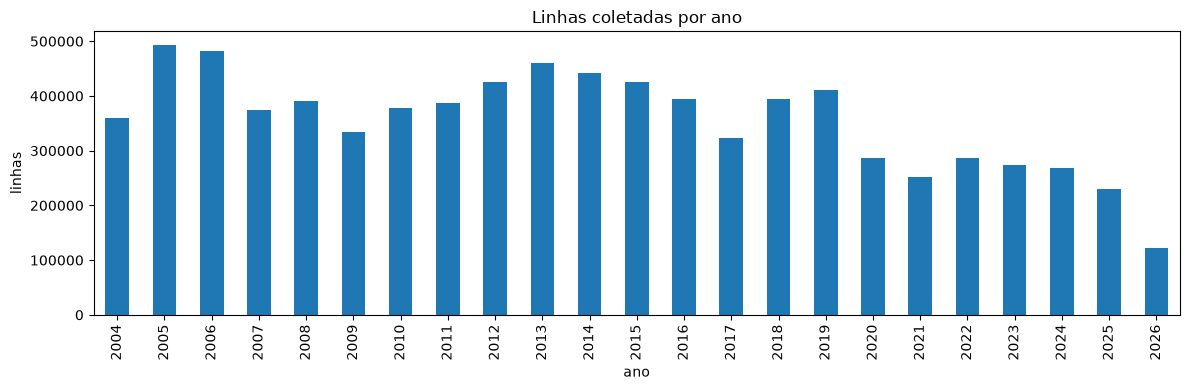

In [8]:
rows_per_year = duckdb.sql(f"""
    select year(data_da_coleta) as ano, count(*) as linhas
    from df_data
    group by 1
    order by 1
""").df()

rows_per_year.plot(x="ano", y="linhas", kind="bar", figsize=(12, 4), legend=False, title="Linhas coletadas por ano")
plt.ylabel("linhas")
plt.tight_layout()
plt.show()

Volume de coleta não é constante: pico em 2005-2006 (~490 mil linhas/ano), queda gradual a partir de 2017, e um patamar bem mais baixo a partir de 2020 (~250-290 mil/ano) - provavelmente reflete mudança na quantidade de postos/revendas reportando ou na periodicidade de coleta da ANP ao longo dos anos, não uma mudança real no mercado. 2026 aparece bem menor porque a série vai só até junho desse ano (ano parcial). Vale ter isso em mente ao comparar estatísticas de períodos diferentes: anos com menos coletas têm médias mais sensíveis a outliers.

# Produtos

In [9]:
by_product = duckdb.sql(f"""
    select coalesce(produto, '(nulo)') as produto, count(*) as linhas
    from df_data
    group by 1
    order by 2 desc
""").df()
by_product

,produto,linhas
0,DIESEL,5697313
1,DIESEL S10,2454333
2,DIESEL S50,44495


DIESEL (comum) domina com 5,7M linhas (70%), DIESEL S10 tem 2,45M (30%), e DIESEL S50 é residual (44 mil, ~0,5%). S50 foi uma variante de transição (menor teor de enxofre que o comum, anterior ao S10) vendida só num período curto - por isso o volume tão baixo. Nas análises abaixo, o S50 tende a ter pouco peso estatístico e a aparecer só numa fatia do eixo temporal.

# Preço de venda - estatísticas por tipo de diesel


In [10]:
diesel_stats = duckdb.sql(f"""
    select
        produto,
        count(*) as n,
        round(avg(valor_de_venda), 3) as preco_medio,
        round(median(valor_de_venda), 3) as preco_mediano,
        round(stddev(valor_de_venda), 3) as desvio_padrao,
        round(min(valor_de_venda), 3) as preco_min,
        round(max(valor_de_venda), 3) as preco_max
    from df_data
    group by 1
    order by 1
""").df()
diesel_stats

,produto,n,preco_medio,preco_mediano,desvio_padrao,preco_min,preco_max
0,DIESEL,5697313,2.562,2.070,1.236,1.020,9.45
1,DIESEL S10,2454333,4.248,3.619,1.496,1.938,9.99
2,DIESEL S50,44495,2.172,2.160,0.125,1.599,2.95


O S10 aparece com preço médio bem mais alto (R$4,25) que o comum (R$2,56), mas isso mistura nível de preço com período histórico - o S10 só passou a ser vendido em maior escala a partir de ~2013 (ver `by_product`/gráfico seguinte), justamente quando o preço nacional já estava mais alto, enquanto o DIESEL comum tem histórico desde 2004 com anos de preço bem mais baixo puxando a média pra baixo. Não dá pra concluir daqui que o S10 é "mais caro" que o comum sem controlar pelo período - o gráfico de spread mais abaixo faz essa comparação corretamente (mesmo mês).

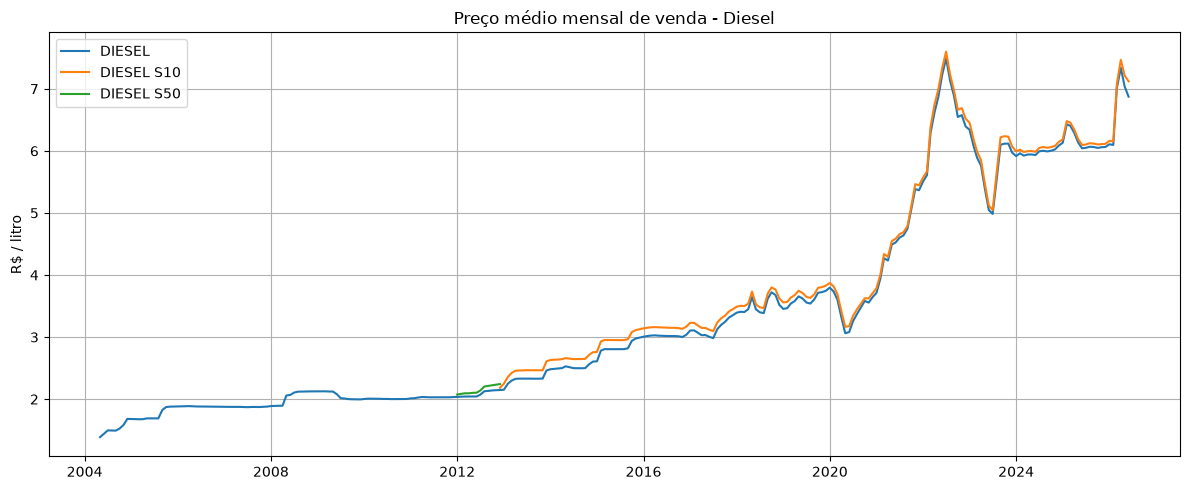

In [11]:
monthly_price = duckdb.sql(f"""
    select
        date_trunc('month', data_da_coleta) as mes,
        produto,
        avg(valor_de_venda) as preco_medio
    from df_data
    group by 1, 2
    order by 1
""").df()

fig, ax = plt.subplots(figsize=(12, 5))
for produto, group in monthly_price.groupby("produto"):
    ax.plot(group["mes"], group["preco_medio"], label=produto)
ax.set_title("Preço médio mensal de venda - Diesel")
ax.set_ylabel("R$ / litro")
ax.legend()
plt.tight_layout()
plt.grid()
plt.show()

DIESEL e DIESEL S10 seguem praticamente coladas a partir de ~2013, confirmando que a diferença de médias da tabela anterior era mesmo efeito de período, não de produto. DIESEL S50 (verde) some do gráfico rapidamente - coerente com o volume residual visto em `by_product`. A curva conjunta é a mesma tendência de alta que aparece nos outros gráficos: praticamente estável até 2015, rampa forte 2016-2022 (pico em torno de 2022), queda abrupta em 2023 e novo patamar mais alto e volátil dali em diante.

# Preço de venda - estatísticas por estado e região do Brasil


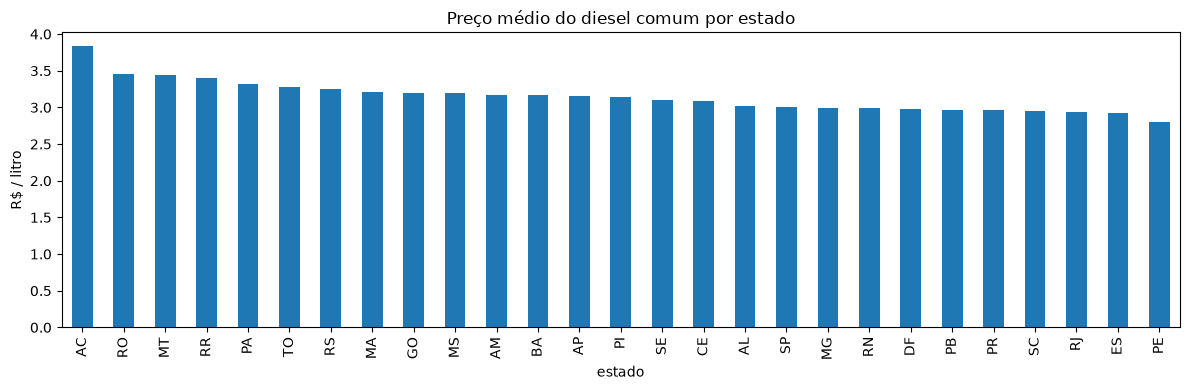

In [12]:
by_state = duckdb.sql(f"""
    select 
        estado_sigla as estado, 
        avg(valor_de_venda) as preco_medio, 
        count(*) as n
    from df_data
    group by 1
    order by 2 desc
""").df()

by_state.plot(x="estado", y="preco_medio", kind="bar", figsize=(12, 4), legend=False, title="Preço médio do diesel comum por estado")
plt.ylabel("R$ / litro")
plt.tight_layout()
plt.show()

AC (Acre) lidera com folga (~R$3,85), seguido por RO, MT, RR, PA, TO - todos estados do Norte/Centro-Oeste, distantes das refinarias e portos do litoral. PE fecha a lista como o mais barato (~R$2,80). O padrão é consistente com custo de frete/logística de distribuição: quanto mais longe da origem do combustível, maior o preço final — o que reforça a lógica de usar o diesel como proxy de custo de frete no projeto.

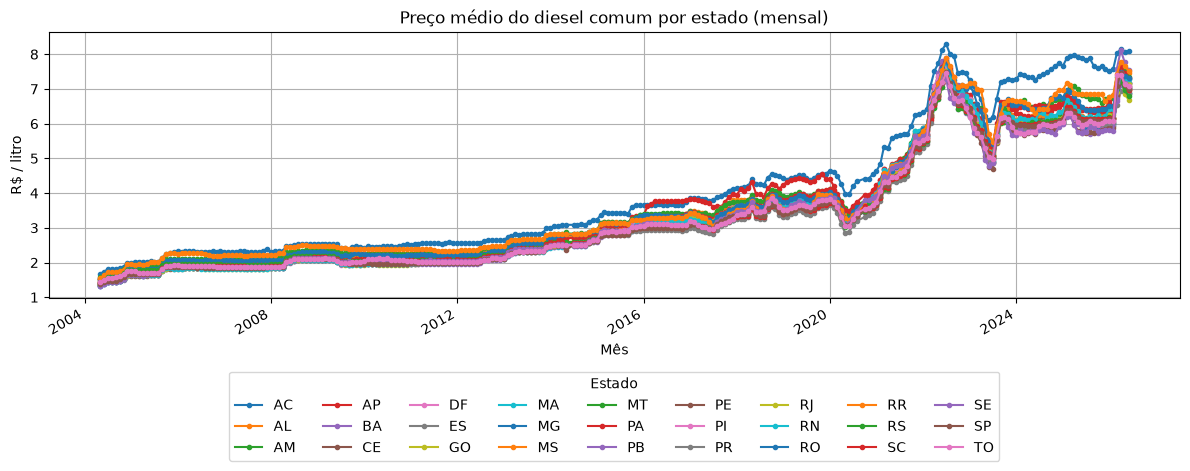

In [13]:
by_state_month = duckdb.sql(f"""
    select
        date_trunc('month', data_da_coleta) as mes,
        estado_sigla as regiao,
        avg(valor_de_venda) as preco_medio,
        count(*) as n
    from df_data
    group by 1, 2
    order by 1, 2
""").df()

pivot = by_state_month.pivot(index="mes", columns="regiao", values="preco_medio")

pivot.plot(kind="line", figsize=(12, 5), marker="o", markersize=3, title="Preço médio do diesel comum por estado (mensal)")
plt.ylabel("R$ / litro")
plt.xlabel("Mês")
plt.legend(title="Estado", loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=9)
plt.tight_layout()
plt.grid()
plt.show()

Com 27 séries sobrepostas fica difícil distinguir estado a estado, mas dá pra confirmar visualmente que o AC (linha azul-escura) se mantém acima do conjunto ao longo de praticamente toda a série — o ranking do gráfico de barras anterior não é um efeito de médio prazo isolado, é persistente desde o início da série.

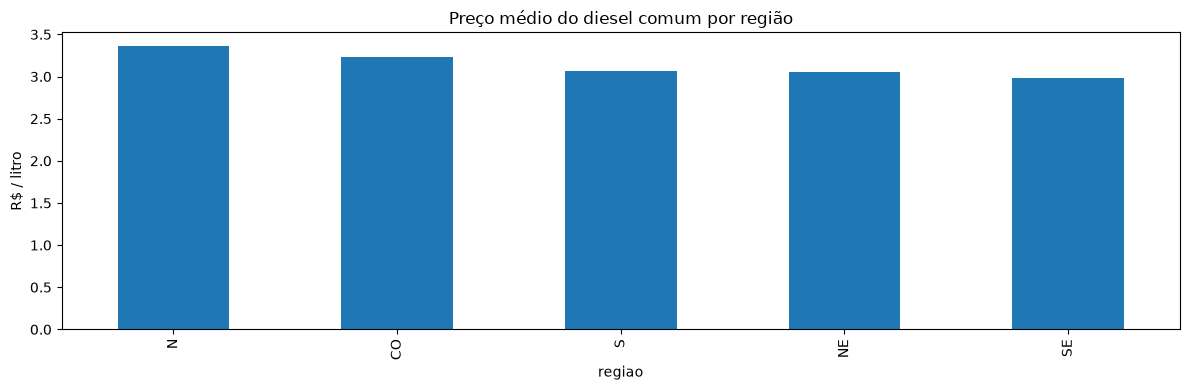

In [14]:
by_region = duckdb.sql(f"""
    select 
        regiao_sigla as regiao, 
        avg(valor_de_venda) as preco_medio, 
        count(*) as n
    from df_data
    group by 1
    order by 2 desc
""").df()

by_region.plot(x="regiao", y="preco_medio", kind="bar", figsize=(12, 4), legend=False, title="Preço médio do diesel comum por região")
plt.ylabel("R$ / litro")
plt.tight_layout()
plt.show()

Agregando por região o padrão se mantém (N mais caro, SE mais barato), mas a amplitude encolhe bastante: ~R$0,38 entre N e SE, contra ~R$1,05 entre AC e PE no gráfico por estado. Faz sentido — região é uma média de estados heterogêneos (ex. o Norte mistura AC/RO/PA, caros, com AM/RR, mais baratos), então agregar nesse nível esconde parte da variação que interessa se o objetivo é usar o diesel como proxy de custo de frete local.

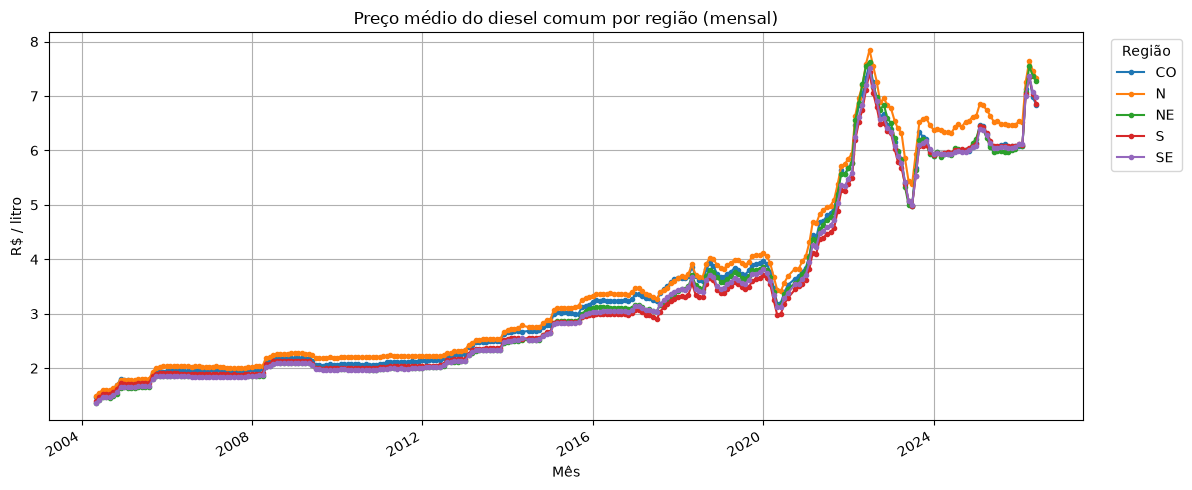

In [15]:
by_region_month = duckdb.sql(f"""
    select
        date_trunc('month', data_da_coleta) as mes,
        regiao_sigla as regiao,
        avg(valor_de_venda) as preco_medio,
        count(*) as n
    from df_data
    group by 1, 2
    order by 1, 2
""").df()

pivot = by_region_month.pivot(index="mes", columns="regiao", values="preco_medio")

pivot.plot(kind="line", figsize=(12, 5), marker="o", markersize=3, title="Preço médio do diesel comum por região (mensal)")
plt.ylabel("R$ / litro")
plt.xlabel("Mês")
plt.legend(title="Região", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.grid()
plt.show()


A região Norte (laranja) fica visivelmente acima das demais durante praticamente toda a série, com o gap se alargando bastante nos picos de preço (2022 e 2026) — sugerindo que choques de preço nacionais chegam amplificados nas regiões mais distantes da cadeia de distribuição, não só deslocados para cima em nível constante.

# Dispersão de preços por estado

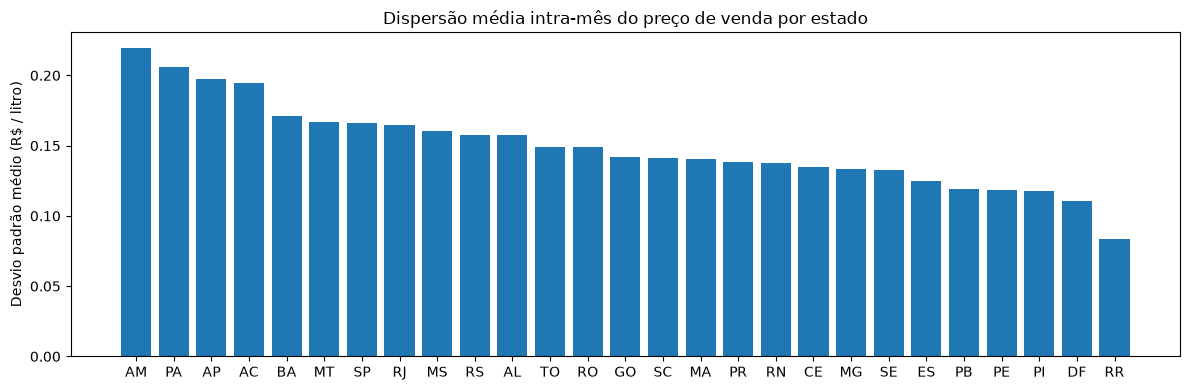

In [16]:
state_month_dispersion = duckdb.sql(f"""
    select
        estado_sigla as estado,
        date_trunc('month', data_da_coleta) as mes,
        stddev(valor_de_venda) as desvio_padrao_mes
    from df_data
    group by 1, 2
""").df()

state_dispersion = (
    state_month_dispersion
    .groupby("estado")["desvio_padrao_mes"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(state_dispersion.index, state_dispersion.values)
ax.set_title("Dispersão média intra-mês do preço de venda por estado")
ax.set_ylabel("Desvio padrão médio (R$ / litro)")
plt.tight_layout()
plt.show()

AM tem a maior dispersão intra-mês (~R$0,22), RR a menor (~R$0,08). Note que isso não segue o mesmo ranking do preço médio por estado: AC lidera em preço médio mas cai para a 4ª posição em dispersão, e RR (preço médio moderado) é o estado mais homogêneo. Ou seja, "caro" e "instável/heterogêneo" são dimensões diferentes — RR provavelmente tem poucas revendas concentradas numa cadeia de suprimento única (baixa dispersão), enquanto AM tem um mercado mais fragmentado geograficamente (rio, estradas precárias) que gera preços bem diferentes entre municípios no mesmo mês.

# Diferencial de preço entre variantes de diesel

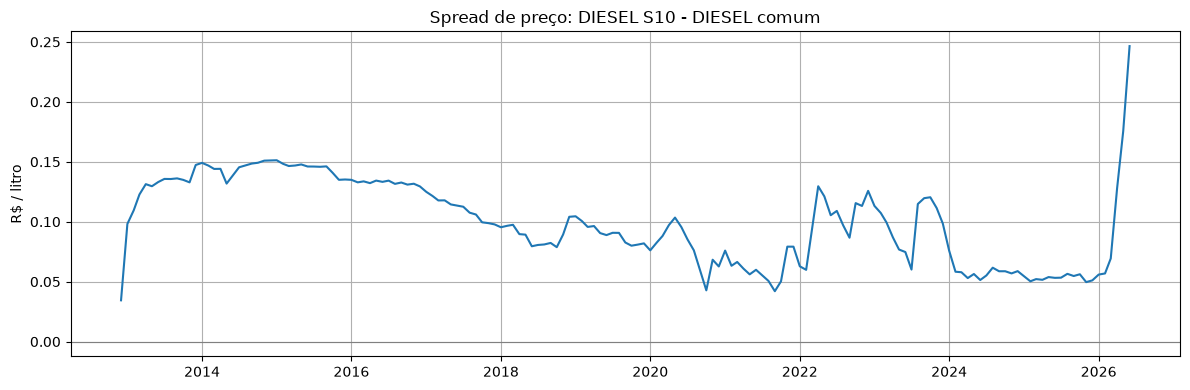

In [17]:
product_spread = monthly_price.pivot(index="mes", columns="produto", values="preco_medio")
product_spread["spread_s10_diesel"] = product_spread["DIESEL S10"] - product_spread["DIESEL"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(product_spread.index, product_spread["spread_s10_diesel"])
ax.set_title("Spread de preço: DIESEL S10 - DIESEL comum")
ax.set_ylabel("R$ / litro")
ax.axhline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.grid()
plt.show()

O spread começa alto (~R$0,15 em 2013-2015, logo após a introdução em maior escala do S10), cai de forma bastante consistente até um patamar de ~R$0,05-0,10 entre 2018 e 2025 — sinal de que o S10 deixou de ser um produto "premium" de nicho e passou a competir de perto com o comum. O salto brusco para ~R$0,25 no fim de 2026 provavelmente é ruído de amostra pequena (os últimos meses da série têm poucas coletas, como visto no gráfico de linhas/ano) e não uma mudança real de comportamento — vale conferir o `n` desses meses antes de usar esse trecho final em qualquer conclusão.

# Preço médio por bandeira (distribuidora)

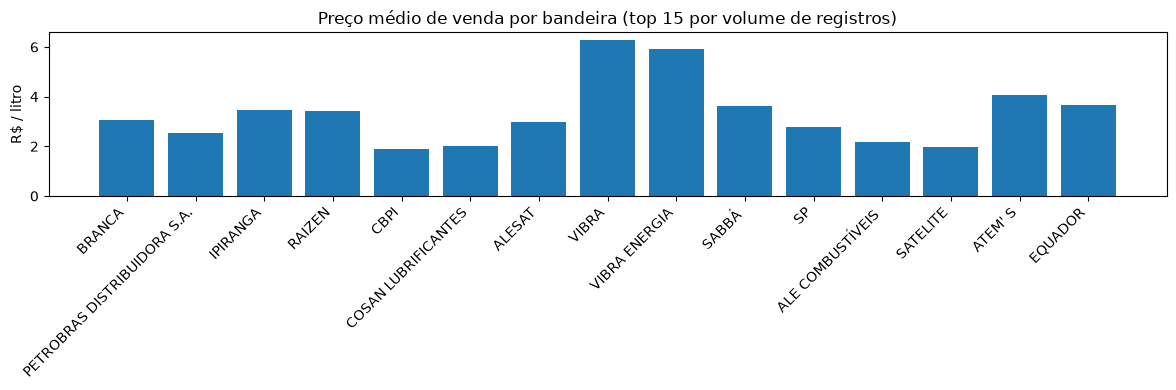

In [18]:
by_bandeira = duckdb.sql(f"""
    select
        coalesce(bandeira, '(nulo)') as bandeira,
        avg(valor_de_venda) as preco_medio,
        count(*) as n
    from df_data
    group by 1
    having count(*) >= 1000
    order by n desc
    limit 15
""").df()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(by_bandeira["bandeira"], by_bandeira["preco_medio"])
ax.set_title("Preço médio de venda por bandeira (top 15 por volume de registros)")
ax.set_ylabel("R$ / litro")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Cuidado, viés de período aqui de novo:** VIBRA e VIBRA ENERGIA aparecem muito acima das demais (~R$6, quase o dobro de BRANCA/IPIRANGA/RAIZEN). Mas "Vibra Energia" é o nome atual da BR Distribuidora/Petrobras Distribuidora após o rebranding de 2021 — ou seja, essa bandeira só existe nos anos mais recentes e caros da série, enquanto bandeiras como BRANCA e IPIRANGA têm histórico desde 2004 (anos baratos) puxando a média pra baixo. Essa comparação não isola efeito de bandeira de efeito de período, igual ao que vimos na tabela `diesel_stats` — pra comparar bandeiras de forma justa seria preciso normalizar por mês (ex. preço da bandeira menos a média nacional do mês), não a média bruta ao longo de toda a série.

# Sazonalidade - decomposição da série nacional mensal

2 mes(es) sem coleta - interpolando linearmente


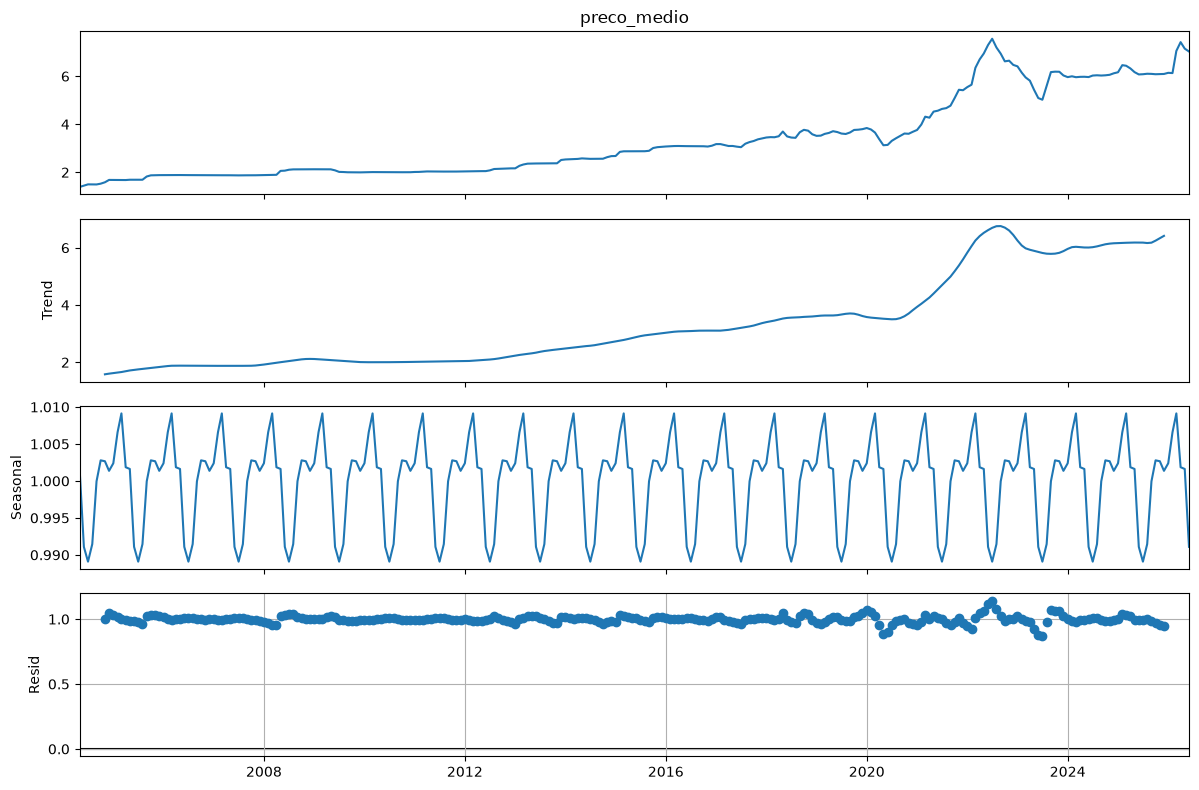

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose

national_monthly = duckdb.sql(f"""
    select
        date_trunc('month', data_da_coleta) as mes,
        avg(valor_de_venda) as preco_medio
    from df_data
    group by 1
    order by 1
""").df().set_index("mes")["preco_medio"].asfreq("MS")

n_faltantes = national_monthly.isna().sum()
if n_faltantes:
    print(f"{n_faltantes} mes(es) sem coleta - interpolando linearmente")
    national_monthly = national_monthly.interpolate(method="linear")

decomposition = seasonal_decompose(national_monthly, model="multiplicative", period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.grid()
plt.show()

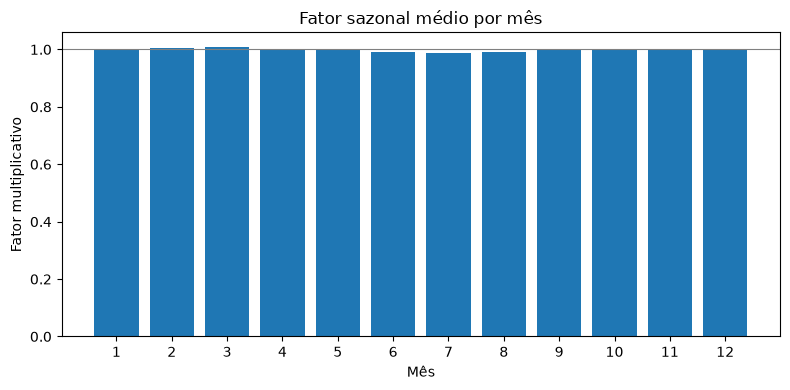

In [20]:
seasonal_by_month = decomposition.seasonal.groupby(decomposition.seasonal.index.month).mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(seasonal_by_month.index, seasonal_by_month.values)
ax.axhline(1.0, color="gray", linewidth=0.8)
ax.set_title("Fator sazonal médio por mês")
ax.set_ylabel("Fator multiplicativo")
ax.set_xlabel("Mês")
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

## Robustez: STL, série completa vs. 2020+ vs. só pós-reforma do ICMS monofásico (2023+)

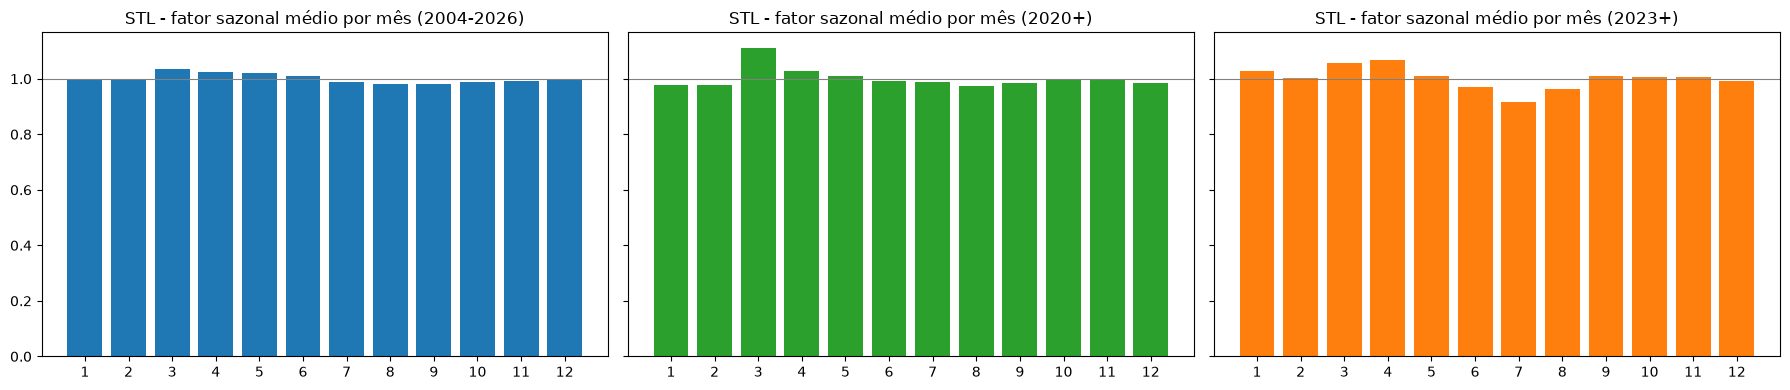

In [21]:
import numpy as np
from statsmodels.tsa.seasonal import STL

national_monthly_2020 = national_monthly["2020":]
national_monthly_recent = national_monthly["2023":]

stl_full = STL(np.log(national_monthly), period=12, robust=True).fit()
stl_2020 = STL(np.log(national_monthly_2020), period=12, robust=True).fit()
stl_recent = STL(np.log(national_monthly_recent), period=12, robust=True).fit()

seasonal_full_by_month = np.exp(stl_full.seasonal).groupby(stl_full.seasonal.index.month).mean()
seasonal_2020_by_month = np.exp(stl_2020.seasonal).groupby(stl_2020.seasonal.index.month).mean()
seasonal_recent_by_month = np.exp(stl_recent.seasonal).groupby(stl_recent.seasonal.index.month).mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

axes[0].bar(seasonal_full_by_month.index, seasonal_full_by_month.values)
axes[0].axhline(1.0, color="gray", linewidth=0.8)
axes[0].set_title("STL - fator sazonal médio por mês (2004-2026)")
axes[0].set_xticks(range(1, 13))

axes[1].bar(seasonal_2020_by_month.index, seasonal_2020_by_month.values, color="tab:green")
axes[1].axhline(1.0, color="gray", linewidth=0.8)
axes[1].set_title("STL - fator sazonal médio por mês (2020+)")
axes[1].set_xticks(range(1, 13))

axes[2].bar(seasonal_recent_by_month.index, seasonal_recent_by_month.values, color="tab:orange")
axes[2].axhline(1.0, color="gray", linewidth=0.8)
axes[2].set_title("STL - fator sazonal médio por mês (2023+)")
axes[2].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

**Conclusão:** o padrão sazonal é pequeno (efeito de poucos % em torno da tendência, dominado pelas variações de política de preço capturadas no resíduo), mas é **real e robusto na direção** - converge em pico no primeiro trimestre/início do segundo e vale em junho-agosto nas três janelas comparadas (série completa 2004-2026, 2020+ e só pós-reforma do ICMS monofásico 2023+):

- Série completa e 2023+: pico suave em **março-abril**, vale em **junho-agosto**.
- 2020+: pico concentrado e mais agudo isoladamente em **março** (abril já cai perto de 1.0), diferente do platô mar-abr das outras duas janelas. Com só ~6 ciclos anuais, um valor atípico em um único março (ex. 2022, auge do choque internacional de preços) pesa desproporcionalmente na média - o `STL` robusto não amortece totalmente esse efeito. Por isso, para magnitude/forma do efeito eu confiaria mais no **2023+** (regime de precificação mais homogêneo, mesmo com menos ciclos) do que no pico isolado do 2020+.

**Hipótese:** o pico no início do ano coincide com o pico da colheita da soja no Centro-Oeste (safra principal, jan-abr), quando a demanda por transporte de carga aumenta e pressiona o preço do diesel para cima. O vale em junho-agosto corresponde ao intervalo de menor movimento agrícola entre a safra principal e a safra de inverno.

**Relevância para o projeto:** se esse ciclo sazonal do diesel (proxy de frete) realmente reflete o calendário de safra, vale checar se um padrão sazonal semelhante (possivelmente defasado) aparece no preço do feijão, já que o feijão tem safras próprias (águas, seca, inverno) que podem ou não coincidir com esse ciclo.

# Variação percentual mensal (MoM) e anual (YoY)

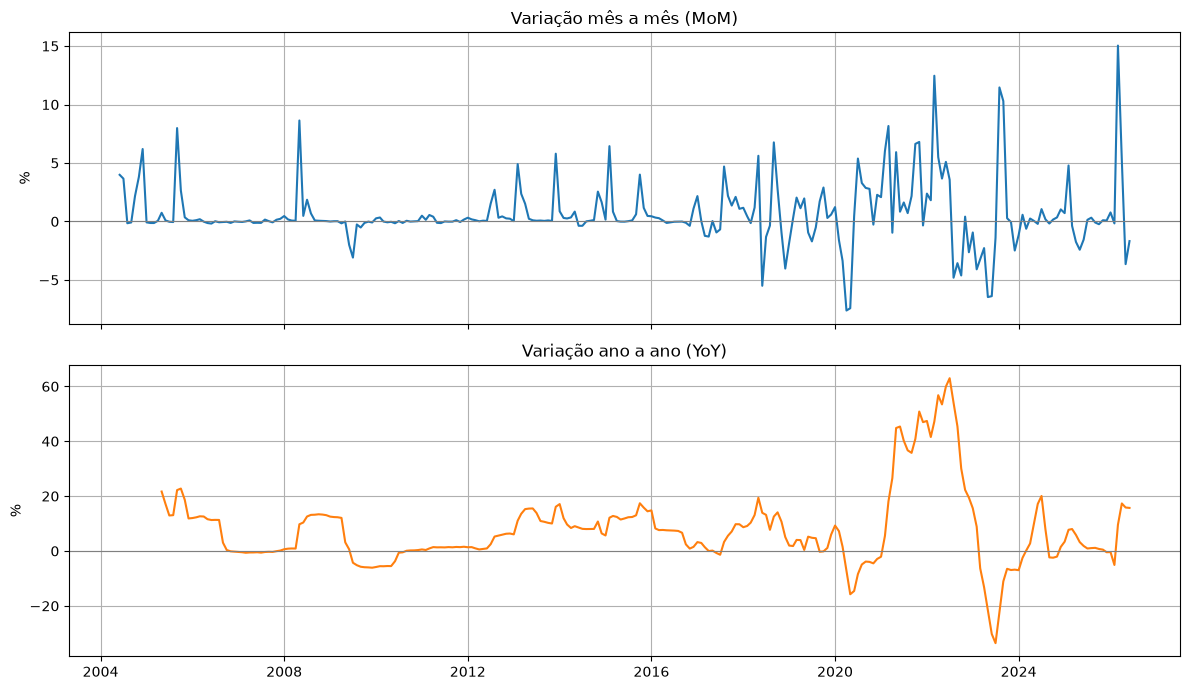

In [22]:
variacao = pd.DataFrame({
    "mom": national_monthly.pct_change(1) * 100,
    "yoy": national_monthly.pct_change(12) * 100,
})

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(variacao.index, variacao["mom"])
axes[0].axhline(0, color="gray", linewidth=0.8)
axes[0].set_title("Variação mês a mês (MoM)")
axes[0].set_ylabel("%")
axes[0].grid()

axes[1].plot(variacao.index, variacao["yoy"], color="tab:orange")
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_title("Variação ano a ano (YoY)")
axes[1].set_ylabel("%")
axes[1].grid()

plt.tight_layout()
plt.show()

O YoY conta a história macro de forma bem clara: queda de ~-30% em 2020 (COVID), disparada até +60% em 2022 (choque internacional/guerra na Ucrânia), e desabamento pra ~-30% em 2023 (reforma do ICMS monofásico eliminando cascata de impostos). Já o MoM nos primeiros anos (2004-2010) mostra picos isolados de até +8% cercados de meses quase parados em 0% - um padrão pouco natural pra preço de combustível, mais consistente com **poucas coletas por mês** nesse período inicial (visto no gráfico de linhas/ano) do que com choques reais mês a mês. Ou seja, o MoM da década de 2000 é mais ruído de amostragem que sinal econômico; o YoY, por suavizar numa janela de 12 meses, é mais confiável para esse período.